In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch 

In [2]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import drop_empty_histograms
from anomaly_detection.utils.preprocess import minmax_scale_per_sample

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [4]:
full_dataset = torch.from_numpy(full_dataset)
full_dataset = full_dataset.to(torch.float32)

In [5]:
from anomaly_detection.config.paths import CHECKPOINT_DIR
from anomaly_detection.models.conv_ae import ConvAE

checkpoint = torch.load(f"{CHECKPOINT_DIR}/conv_autoenc_v1.pth", map_location="cpu")

config = checkpoint["config"]

model = ConvAE()
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

ConvAE(
  (encoder): Sequential(
    (0): Conv1d(1, 1, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(1, 1, kernel_size=(3,), stride=(2,), padding=(1,))
    (4): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(1, 1, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv1d(1, 1, kernel_size=(3,), stride=(2,), padding=(1,))
    (10): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Conv1d(1, 1, kernel_size=(3,), stride=(1,), padding=(1,))
    (13): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Conv1d(1, 1, kernel_size=(3,), stride=(2,), padding=(1,))
    (16): BatchNorm1d(1, eps=1e-05, mom

In [6]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Model consists of", trainable_params, "trainable parameters.")

Model consists of 8712 trainable parameters.


In [7]:
from anomaly_detection.utils.test_and_eval import get_outliers

outs = get_outliers(full_dataset)

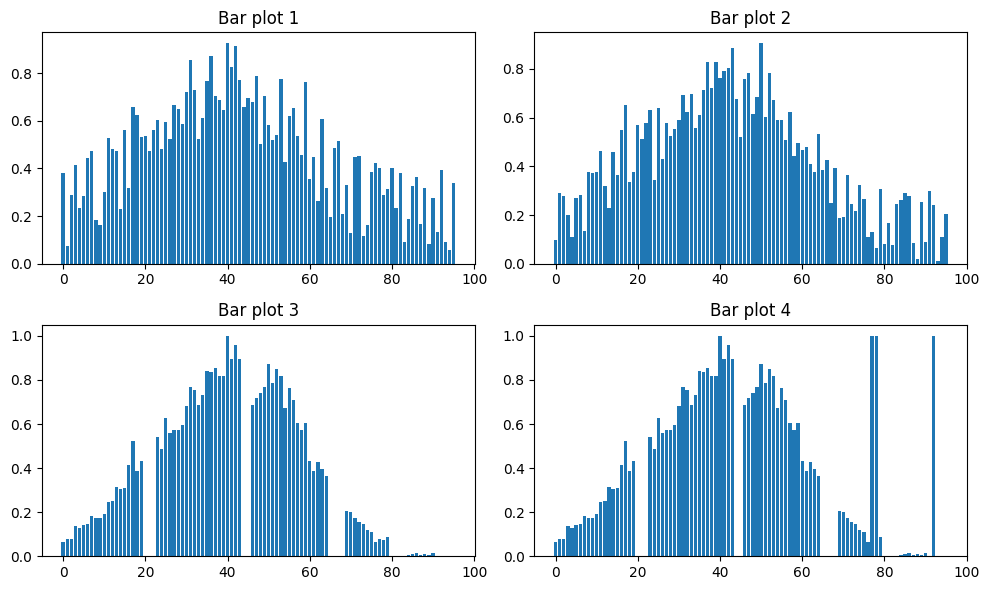

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for i, (ax, data) in enumerate(zip(axes, outs)):
    ax.bar(range(len(data)), data)
    ax.set_title(f"Bar plot {i+1}")

plt.tight_layout()
plt.show()

In [22]:
# TODO: move it somewhere to autoencoders or sht
def score_points(pts, model, criterion=None):
    if not criterion:
        import torch
        criterion = torch.nn.MSELoss()

    out_scores = []
    for out in pts:
        out = out.reshape(1, 1, 96)
        pred = model(out).detach()
        loss = criterion(pred, out).detach().numpy()
        out_scores.append(loss)
        
    return out_scores

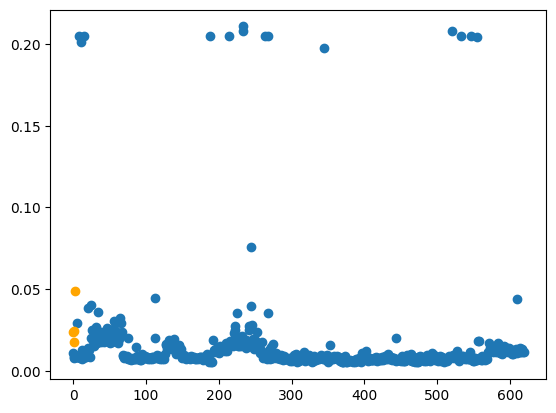

In [24]:
criterion = torch.nn.MSELoss()
score = score_points(full_dataset, model, criterion)
out_score = score_points(outs, model, criterion)

plt.scatter(range(len(score)), score)
plt.scatter(range(len(out_score)), out_score, color='orange')

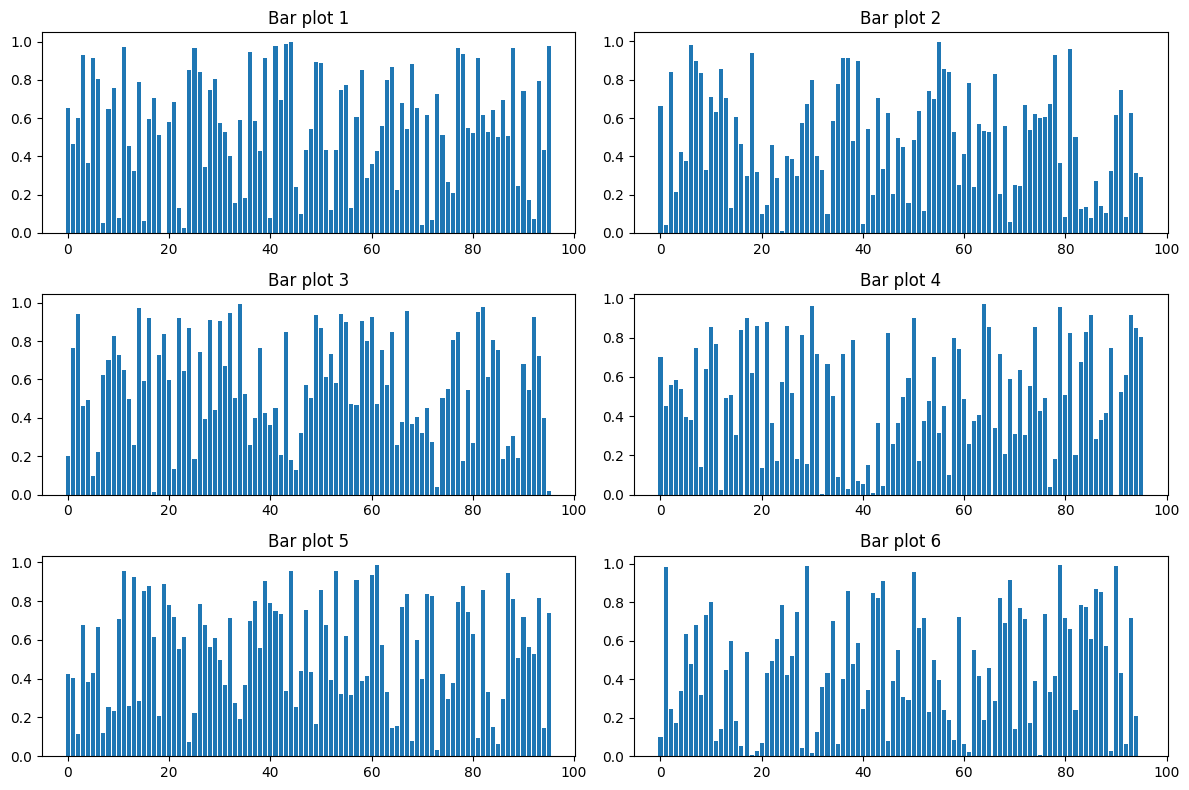

In [25]:
randoms = [torch.rand(96) for _ in range(6)]

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (ax, data) in enumerate(zip(axes, randoms)):
    ax.bar(range(len(data)), data)
    ax.set_title(f"Bar plot {i+1}")

plt.tight_layout()
plt.show()

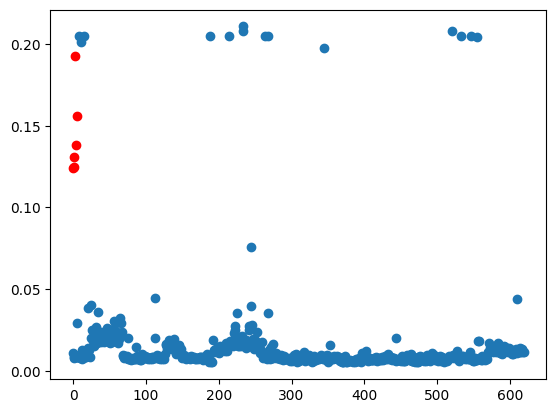

In [27]:
rand_scores = score_points(randoms, model)

plt.scatter(range(len(score)), score)
plt.scatter(range(len(rand_scores)), rand_scores, color='red')
plt.show()